# Import the necessary libraries and modules

In [5]:
import torch  # PyTorch library for deep learning
import torch.nn as nn  # Neural network modules and loss functions
import pennylane as qml  # PennyLane for quantum machine learning
import numpy as np  # NumPy library for numerical computations
import matplotlib.pyplot as plt  # Plotting library for visualization
from matplotlib.ticker import ScalarFormatter  # Formatter for scientific notation in plots
dtype = torch.float  # Set default tensor data type to float

In [6]:
def Solution(t, params):
    # Analytical solution of the damped harmonic oscillator for comparison
    A, omega, beta = params
    return A * torch.exp(-beta * t) * torch.cos(np.sqrt((omega**2) - (beta**2)) * t)

def test_PINN(NN, domain, params, num_test):
    # Evaluate the neural network against the analytical solution and compute error metrics
    t = torch.linspace(domain[0], domain[1], num_test).view(-1, 1)
    pred_solution = NN(t)
    exact_solution = Solution(t, params)
    residual_error = pred_solution - exact_solution

    l2_error = (exact_solution - pred_solution)**2
    l2_metric = torch.mean(l2_error)

    abs_error = torch.abs(exact_solution - pred_solution)
    MAE = torch.mean(abs_error)
    percent_MAE = MAE * 100
    return t, pred_solution, residual_error, l2_error, l2_metric, MAE, percent_MAE


In [7]:
# Set the necessary parameters
A , k, m, b = 0.5, 9, 1, 1.6
omega = np.sqrt(k/m)
beta = b / (2*m)
params = [A, omega, beta]
domain, num_test = [0.0, 8.0], 500
seed = 42

# Classical Neural Network

In [8]:
classic_model_list = []
classic_history_lists = []

def init_weights(m):
    """
    Initializes weights and biases for a linear layer.

    Args:
        m (nn.Linear): The linear layer to initialize.

    Notes:
        - Applies uniform weight initialization within the range [-n0, n0].
        - Initializes biases with a constant value of 0.01.
    """
    if isinstance(m, nn.Linear):
        out_sz = torch.tensor(m.out_features)
        n0 = 1.0/torch.sqrt(out_sz)
        m.weight.data.uniform_(-n0, n0)
        # m.bias.data.fill_(0.01)

class CNeuralNet(nn.Module):
    """
    Classical neural network class.

    Args:
        input_size (int): Size of the input features.
        hidden_size (int): Number of hidden units in the neural network.
        output_size (int): Size of the output.

    Attributes:
        fnn (nn.Sequential): Feedforward neural network with three linear layer followed by a Silu activation.

    Notes:
        - The classical neural network architecture consists of three hidden layers.
        - The input layer has 'input_size' neurons.
        - The output layer has 'output_size' neurons.
    """
    def __init__(self, input_size, hidden_size, output_size):
        super(CNeuralNet, self).__init__()
        self.fnn = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.SiLU(),
            nn.Linear(hidden_size, output_size),
        )

        self.fnn.apply(init_weights)

    def forward(self, x):
        """
        Forward pass through the neural network.

        Args:
            x (torch.Tensor): Input data.

        Returns:
            torch.Tensor: Outputs predictions from the neural network.
        """
        out = self.fnn(x)
        out = out[:, 0]*out[:, 1]
        out = out.view(-1, 1)
        return out





for idx, hs in enumerate([10, 30, 50]):
    idx = idx + 1
    input_size , hidden_size, output_size = 1, hs, 2
    model_classic = CNeuralNet(input_size, hidden_size, output_size)
    model_classic.load_state_dict(torch.load(f"..\\trained_models\\classical damped harmonic oscillator\\{seed}\\Classical_model_{seed}_{hs}.pth"))
    classic_model_list.append(model_classic)
    classic_history_lists.append(torch.load(f"..\\trained_models\\classical damped harmonic oscillator\\{seed}\\loss_Classical_model_{seed}_{hs}.pt"))

In [9]:
# Unpack the classical models and their corresponding training histories
cmodel1, cmodel2, cmodel3 = classic_model_list
c_hist1, c_hist2, c_hist3 = classic_history_lists

In [10]:
# Extract the minimum training loss for each classical model and store it in a list
cmin_loss_list = []
for idx in range(len(classic_model_list)):
    cmin_loss_list.append(min(classic_history_lists[idx][0]))

In [11]:
# Evaluate each classical model on the test dataset and store performance metrics
cl2_error_list = []
cl2_metric_list = []
cpred_list = []
cMAE_list = []
cpercent_MAE = []
cresidual_error_list = []

for idx in range(len(classic_model_list)):
    print(100*"=")
    print(f"case{idx+1}: loaded\n")
    t, pred_solution, residual_error, l2_error, l2_metric, MAE, percent_MAE = test_PINN(classic_model_list[idx], domain, params, num_test)
    cresidual_error_list.append(residual_error)
    cl2_error_list.append(l2_error)
    cl2_metric_list.append(l2_metric)
    cpred_list.append(pred_solution)
    cMAE_list.append(MAE)
    cpercent_MAE.append(percent_MAE)

case1: loaded

case2: loaded

case3: loaded



# Quantum Neural Network

In [12]:
quantum_model_list = []
quantum_history_lists = []

# Set the number of qubits to 3
n_qubits = 2
# Create a quantum device with 3 qubits
dev = qml.device("default.qubit", wires=n_qubits)

def RY_layer(w):
    """
    Apply a layer of single-qubit rotations around the Y-axis (RY gates).

    Args:
        w (torch.Tensor): List of rotation angles for each qubit.
    """
    for idx, element in enumerate(w):
        qml.RY(element, wires=idx)

def entangling_layer(nqubits):
    """
    Apply an entangling layer of CNOT gates to adjacent qubits.

    Args:
        nqubits (int): Number of qubits in use.
    """
    for i in range(0, nqubits - 1):
        qml.CNOT(wires=[i, i + 1])

@qml.qnode(dev)
def quantum_net(input_features, n_qubits, ansatz_depth, feature_weights, ansatz_weights, out_weights):
    """
    Quantum circuit

    Args:
        input_features (torch.Tensor): Input features.
        n_qubits (int): Number of qubits in the circuit.
        ansatz_depth (int): Depth of the ansatz (number of layers).
        feature_weights (torch.Tensor): List of parameters
        ansatz_weights (torch.Tensor): List of parameters
        out_weights (torch.Tensor): List of parameters

    Returns:
        tuple: Tuple of expectation values for Pauli-Z operators on qubits 0 and 1 as the solution.
    """
    # apply feature map layers
    temp1 = feature_weights[0]*input_features[0]
    temp2 = feature_weights[1]*input_features[0]
    qml.exp(qml.PauliZ(0), temp1[0])
    qml.exp(qml.PauliZ(1), temp2[0])
    entangling_layer(n_qubits)
    temp3 = feature_weights[2]*(input_features[0])
    temp4 = feature_weights[3]*(input_features[0])
    qml.RY(temp3, wires=0)
    qml.RY(temp4, wires=1)
    entangling_layer(n_qubits)

    # apply ansatz layers
    for k in range(ansatz_depth):
        RY_layer(ansatz_weights[k])
        entangling_layer(n_qubits)

    # Compute expectation values for Pauli-Z operators
    exp_vals = [qml.expval(out_weights[0]*(qml.PauliZ(0)@qml.PauliZ(1)))]
    return tuple(exp_vals)


class QNeuralNet(nn.Module):
    """
    quantum neural network class.

    Args:
        n_qubits (int): Number of qubits in the circuit.
        feature_depth (int): Depth of the feature map (number of layers).
        ansatz_depth (int): Depth of the ansatz (number of layers).

    Notes:
        - The quantum neural network architecture consists of two qubits.
        - The feature map has 'feature_depth' layers.
        - The ansatz has 'ansatz_depgh' layers.
    """
    def __init__(self, n_qubits, feature_depth, ansatz_depth):
        super(QNeuralNet, self).__init__()

        # Set the number qubits, number of ansatz layer and feature map layers
        self.n_qubits = n_qubits
        self.ansatz_depth = ansatz_depth
        self.feature_depth = feature_depth
        
        # Initialize parameters of quantum circuit
        self.feature_weights = nn.Parameter(0.1*torch.randn((feature_depth*n_qubits + 2)).view(-1, 1))
        self.ansatz_weights = nn.Parameter(torch.randn(ansatz_depth*n_qubits).view(ansatz_depth, n_qubits))
        self.out_weights = nn.Parameter(torch.randn((1)))

    def forward(self, x):
        """
        Forward pass through the neural network.

        Args:
            x (torch.Tensor): Input data.

        Returns:
            torch.Tensor: Outputs predictions from the neural network.
        """
        # Initialize an empty tensor for quantum output
        q_out = torch.Tensor(0, 1)

        for elem in x:
            # Apply the quantum circuit (quantum_net) to each input element
            q_out_elem = torch.hstack(tuple(quantum_net(elem, self.n_qubits, self.ansatz_depth, self.feature_weights,self.ansatz_weights, self.out_weights))).float().unsqueeze(0)
            q_out = torch.cat((q_out, q_out_elem)) # Concatenate quantum outputs

        return q_out

for idx, layer in enumerate([1, 2, 3]):
    idx = idx + 1
    feature_depth, ansatz_depth = 1, layer
    model_quantum = QNeuralNet(n_qubits, feature_depth, ansatz_depth)
    model_quantum.load_state_dict(torch.load(f"..\\trained_models\\quantum damped harmonic oscillator\\{seed}\\Quantum_model_{seed}_{layer}.pth"))
    quantum_model_list.append(model_quantum)
    quantum_history_lists.append(torch.load(f"..\\trained_models\\quantum damped harmonic oscillator\\{seed}\\loss_Quantum_model_{seed}_{layer}.pt"))

In [13]:
# Unpack quantum models and their corresponding training histories
qmodel1, qmodel2, qmodel3 = quantum_model_list
q_hist1, q_hist2, q_hist3 = quantum_history_lists

In [14]:
# Extract the minimum training loss for each quantum model and store in a list
qmin_loss_list = []
for idx in range(len(quantum_model_list)):
    qmin_loss_list.append(min(quantum_history_lists[idx][0]))

In [15]:
# Evaluate each quantum model on the test dataset and collect performance metrics
ql2_error_list = []
ql2_metric_list = []
qpred_list = []
qMAE_list = []
qpercent_MAE = []
qresidual_error_list = []

for idx in range(len(quantum_model_list)):
    print(100*"=")
    print(f"case{idx+1}: loaded\n")
    t, pred_solution, residual_error, l2_error, l2_metric, MAE, percent_MAE = test_PINN(quantum_model_list[idx], domain, params, num_test)
    qresidual_error_list.append(residual_error)
    ql2_error_list.append(l2_error)
    ql2_metric_list.append(l2_metric)
    qpred_list.append(pred_solution)
    qMAE_list.append(MAE)
    qpercent_MAE.append(percent_MAE)

case1: loaded

case2: loaded

case3: loaded



# Hybrid Quantum Neural Network

In [16]:
hybrid_model_list = []
hybrid_history_lists = []
# Set the number of qubits to 3
n_qubits = 3
# Create a quantum device with 3 qubits
dev = qml.device("default.qubit", wires=n_qubits)

def RY_layer(w):
    """
    Apply a layer of single-qubit rotations around the Y-axis (RY gates).

    Args:
        w (torch.Tensor): List of rotation angles for each qubit.
    """
    for idx, element in enumerate(w):
        qml.RY(element, wires=idx)

def entangling_layer(nqubits):
    """
    Apply an entangling layer of CNOT gates to adjacent qubits.

    Args:
        nqubits (int): Number of qubits in use.
    """
    for i in range(0, nqubits - 1):
        qml.CNOT(wires=[i, i + 1])

def init_weights(m):
    """
    Initializes weights and biases for a linear layer.

    Args:
        m (nn.Linear): The linear layer to initialize.

    Notes:
        - Applies uniform weight initialization within the range [-n0, n0].
        - Initializes biases with a constant value of 0.01.
    """
    if isinstance(m, nn.Linear):
        out_sz = torch.tensor(m.out_features)
        n0 = 1.0/torch.sqrt(out_sz)
        m.weight.data.uniform_(-n0, n0)
        # m.bias.data.fill_(0.01)

@qml.qnode(dev)
def hquantum_net(input_features, n_qubits, q_depth, q_weights):
    """
    Quantum circuit as a part of quantum hybrid neural network.

    Args:
        input_features (torch.Tensor): Input features.
        n_qubits (int): Number of qubits in the circuit.
        q_depth (int): Number of quantum layers.
        q_weights (torch.Tensor): List of parameters.
    Returns:
        tuple: Tuple of expectation values for Pauli-Z operators on qubits 0, 1, and 2.
    """

    RY_layer(input_features[0])

    entangling_layer(n_qubits)
    RY_layer(input_features[1])
    RY_layer(q_weights[0])

    entangling_layer(n_qubits)
    RY_layer(input_features[2])
    RY_layer(q_weights[1])

    entangling_layer(n_qubits)
    RY_layer(input_features[3])
    RY_layer(q_weights[2])

    exp_vals = [qml.expval(qml.PauliZ(position)) for position in range(0, n_qubits)]
    return tuple(exp_vals)

class HQNeuralNet(nn.Module):
    """
    quantum hybrid neural network class.

    Args:
        input_size (int): Size of the input features.
        hidden_size (int): Number of hidden units in the neural network.
        n_qubits (int): Number of qubits in the circuit.
        q_depth (int): Number of quantum layers.
        output_size (int): Size of the output.

    Attributes:
        fnn (nn.Sequential): Feedforward neural network with a linear layer followed by a Tanh activation.

    Notes:
        - The first classical neural network architecture consists of one hidden layer.
        - The input layer has 'input_size' neurons.
        - The hidden layers has 'hidden_size' neurons with a Tanh activation.
        - The quantum neural network architecture consists of 'n_qubits' and 'q_depth ' layers.
        - The second classical neural network architecture consists of one linear layer.
        - The output layer has 'output_size' neurons.
    """
    def __init__(self, input_size, hidden_size, n_qubits, q_depth, output_size):
        super(HQNeuralNet, self).__init__()
        
        # Define the feedforward neural network (fnn)
        self.fnn = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.SiLU(),
            nn.Linear(hidden_size, (q_depth+1)*n_qubits),
        )
        self.fnn.apply(init_weights)

        #Define the feedforward (n_qubits, output_size) layer as a output layer
        self.output_layer = nn.Linear(n_qubits, output_size)
        self.output_layer.apply(init_weights)

        # Set the number qubits, number of quantum layers
        self.n_qubits = n_qubits
        self.q_depth = q_depth
        
        # Initialize parameters of quantum circuit
        self.q_weights = nn.Parameter(0.2*torch.randn(q_depth * n_qubits).view(q_depth, n_qubits))

    def forward(self, x):
        """
        Forward pass through the neural network.

        Args:
            data (torch.Tensor): Input data.

        Returns:
            torch.Tensor: Outputs predictions from the neural network.
        """
        # Pass the data through the feedforward neural network (self.fnn)
        out = self.fnn(x)
        # Initialize an empty tensor for quantum output
        q_out = torch.Tensor(0, self.n_qubits)
        
        for elem in out:
            # Apply the quantum circuit (hquantum_net) to each output element
            elem = elem.view((self.q_depth+1), self.n_qubits)
            q_out_elem = torch.hstack(tuple(hquantum_net(elem, self.n_qubits, self.q_depth, self.q_weights))).float().unsqueeze(0)
            q_out = torch.cat((q_out, q_out_elem))
            
        # Pass the output of quantum circuit through the feedforward linear layer then combine outputs
        out = self.output_layer(q_out)
        out1 = out[:, 0].view(-1, 1)
        out2 = out[:, 1].view(-1, 1)
        return out1*out2

for idx, hs in enumerate([10, 30, 50]):
    idx = idx + 1
    input_size, hidden_size, q_depth, output_size = 1, hs, 3, 2
    model_hybrid = HQNeuralNet(input_size, hidden_size, n_qubits, q_depth, output_size)
    model_hybrid.load_state_dict(torch.load(f"..\\trained_models\\hybrid damped harmonic oscillator\\{seed}\\hybrid_model_{seed}_{hs}.pth"))
    hybrid_model_list.append(model_hybrid)
    hybrid_history_lists.append(torch.load(f"..\\trained_models\\hybrid damped harmonic oscillator\\{seed}\\loss_hybrid_model_{seed}_{hs}.pt"))

In [17]:
# Unpack hybrid quantum-classical models and their corresponding training histories
hmodel1, hmodel2, hmodel3 = hybrid_model_list
h_hist1, h_hist2, h_hist3 = hybrid_history_lists

In [18]:
# Extract the minimum training loss for each hybrid model and store in a list
hmin_loss_list = []
for idx in range(len(hybrid_model_list)):
    hmin_loss_list.append(min(hybrid_history_lists[idx][0]))

In [19]:
# Evaluate each hybrid model on the test dataset and collect performance metrics
hl2_error_list = []
hl2_metric_list = []
hpred_list = []
hMAE_list = []
hpercent_MAE = []
hresidual_error_list = []

for idx in range(len(hybrid_model_list)):
    print(100*"=")
    print(f"case{idx+1}: loaded\n")
    t, pred_solution, residual_error, l2_error, l2_metric, MAE, percent_MAE = test_PINN(hybrid_model_list[idx], domain, params, num_test)
    hresidual_error_list.append(residual_error)
    hl2_error_list.append(l2_error)
    hl2_metric_list.append(l2_metric)
    hpred_list.append(pred_solution)
    hMAE_list.append(MAE)
    hpercent_MAE.append(percent_MAE)

case1: loaded

case2: loaded

case3: loaded



# compare three nets

In [20]:
# Print summary of classical neural network performance for each hidden size
print(">>Classic neural network<<")
for idx, hs in enumerate([10, 30, 50]):
    print(f"hidden_size:{hs} | minimum of loss function =", cmin_loss_list[idx])
    print(f"f(t)             | MSE =", cl2_metric_list[idx].item())
    print("\n")

>>Classic neural network<<
hidden_size:10 | minimum of loss function = 2.9961072868900374e-05
f(t)             | MSE = 6.087724955250451e-07


hidden_size:30 | minimum of loss function = 6.692036549793556e-05
f(t)             | MSE = 1.1545688494152273e-06


hidden_size:50 | minimum of loss function = 5.040436371928081e-05
f(t)             | MSE = 8.240865554398624e-07




In [21]:
# Print summary of quantum neural network performance for each number of layers
print(">>Quantum neural network<<")
for idx, hs in enumerate([1, 2, 3]):
    print(f"number of layers:{hs} | minimum of loss function=", qmin_loss_list[idx])
    print(f"f(t)                  | MSE =", ql2_metric_list[idx].item())
    print("\n")

>>Quantum neural network<<
number of layers:1 | minimum of loss function= 9.14782383176771e-09
f(t)                  | MSE = 7.105315641409149e-11


number of layers:2 | minimum of loss function= 6.179489558943985e-11
f(t)                  | MSE = 2.5208461620213063e-12


number of layers:3 | minimum of loss function= 1.5552008392205607e-07
f(t)                  | MSE = 3.5043388191269287e-09




In [22]:
# Print summary of hybrid neural network performance for each hidden size
print(">>Hybrid neural network<<")
for idx, hs in enumerate([10, 30, 50]):
    print(f"hidden_size:{hs} | minimum of loss function=", hmin_loss_list[idx])
    print(f"f(t)             | MSE =", hl2_metric_list[idx].item())
    print("\n")

>>Hybrid neural network<<
hidden_size:10 | minimum of loss function= 6.071763436921174e-06
f(t)             | MSE = 5.1335415918174476e-08


hidden_size:30 | minimum of loss function= 2.4432136342511512e-05
f(t)             | MSE = 3.319933341572323e-07


hidden_size:50 | minimum of loss function= 1.0443987775943242e-05
f(t)             | MSE = 7.025391823844984e-08




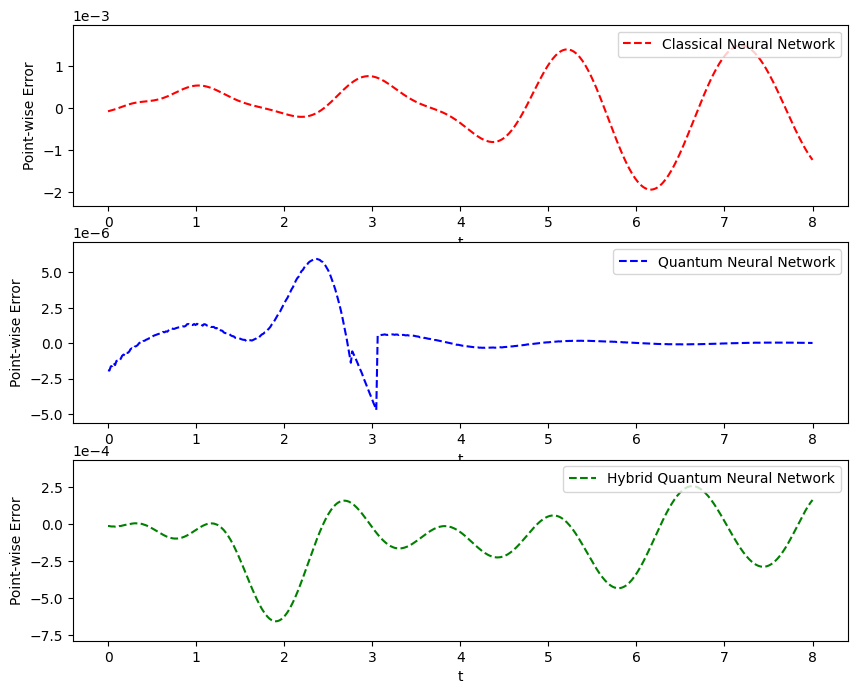

In [23]:
# Plot point-wise error for classical, quantum, and hybrid neural networks across the domain
fig, axs = plt.subplots(3, 1, figsize=(10, 8))

# Plot for Classical Neural Network
axs[0].plot(t.cpu(), cresidual_error_list[0].detach().numpy(), linestyle="dashed", color="r", label='Classical Neural Network')
axs[0].set_ylim(1.2*min(cresidual_error_list[0].detach().numpy()), 1.33*max(cresidual_error_list[0].detach().numpy()))

axs[0].set_xlabel('t')
axs[0].set_ylabel('Point-wise Error')
axs[0].legend(loc='upper right')
axs[0].yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
axs[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))


# Plot for Quantum Neural Network
axs[1].plot(t.cpu(), qresidual_error_list[1].detach().numpy(), linestyle="dashed", color="b", label='Quantum Neural Network')
axs[1].set_ylim(1.2*min(qresidual_error_list[1].detach().numpy()), 1.2*max(qresidual_error_list[1].detach().numpy()))

axs[1].set_xlabel('t')
axs[1].set_ylabel('Point-wise Error')
axs[1].legend(loc='upper right')
axs[1].yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
axs[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

# Plot for Hybrid Neural Network
axs[2].plot(t.cpu(), hresidual_error_list[0].detach().numpy(), linestyle="dashed", color="g", label='Hybrid Quantum Neural Network')
axs[2].set_ylim(1.2*min(hresidual_error_list[0].detach().numpy()), 1.7*max(hresidual_error_list[0].detach().numpy()))

axs[2].set_xlabel('t')
axs[2].set_ylabel('Point-wise Error')
axs[2].legend(loc='upper right')
axs[2].yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
axs[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.show()

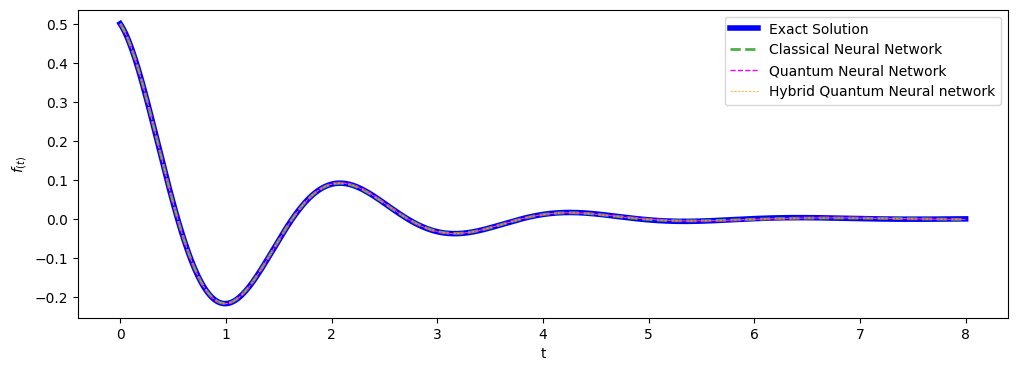

In [24]:
# Plot predicted solutions from classical, quantum, and hybrid neural networks alongside the exact solution
exact_solution = Solution(t, params)
fig2, ax2 = plt.subplots(figsize=(12, 4))
ax2.plot(t.cpu(), exact_solution.cpu().detach().numpy(), label="Exact Solution", color="blue", linewidth=4)
ax2.plot(t.cpu(), cpred_list[0].cpu().detach().numpy(), label="Classical Neural Network",color="#4daf4a", linestyle='dashed', linewidth=2)
ax2.plot(t.cpu(), cpred_list[1].cpu().detach().numpy(), label="Quantum Neural Network",color="magenta", linestyle='dashed', linewidth=1)
ax2.plot(t.cpu(), cpred_list[0].cpu().detach().numpy(), label="Hybrid Quantum Neural network",color="orange", linestyle='dashed', linewidth=0.5)
ax2.set(xlabel="t", ylabel="$f_{(t)}$")
ax2.legend()
plt.show()

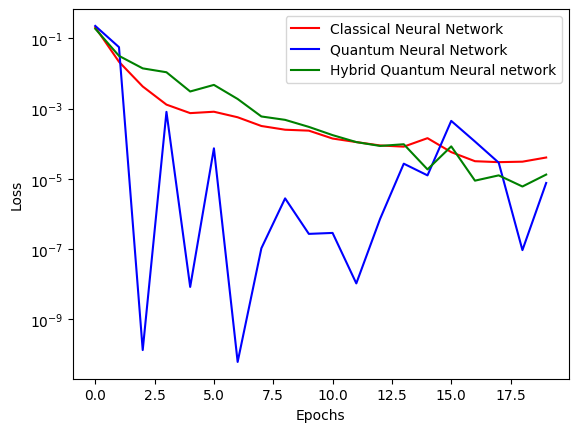

In [25]:
# Plot loss function versus epochs on a semilogarithmic scale for classical, quantum, and hybrid neural networks
plt.semilogy(c_hist1[0], label="Classical Neural Network", color="r")
plt.semilogy(q_hist2[0], label="Quantum Neural Network", color="b")
plt.semilogy(h_hist1[0], label="Hybrid Quantum Neural network", color="green")
plt.legend(loc='upper right')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

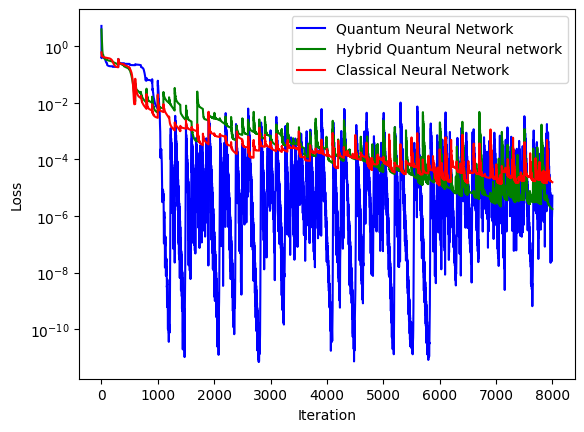

In [26]:
# Plot loss function versus iteration on a semilogarithmic scale for classical, quantum, and hybrid neural networks

plt.semilogy(q_hist2[4], label="Quantum Neural Network", color="b")
plt.semilogy(h_hist1[4], label="Hybrid Quantum Neural network", color="green")
plt.semilogy(c_hist1[4], label="Classical Neural Network", color="r")
plt.legend(loc='upper right')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

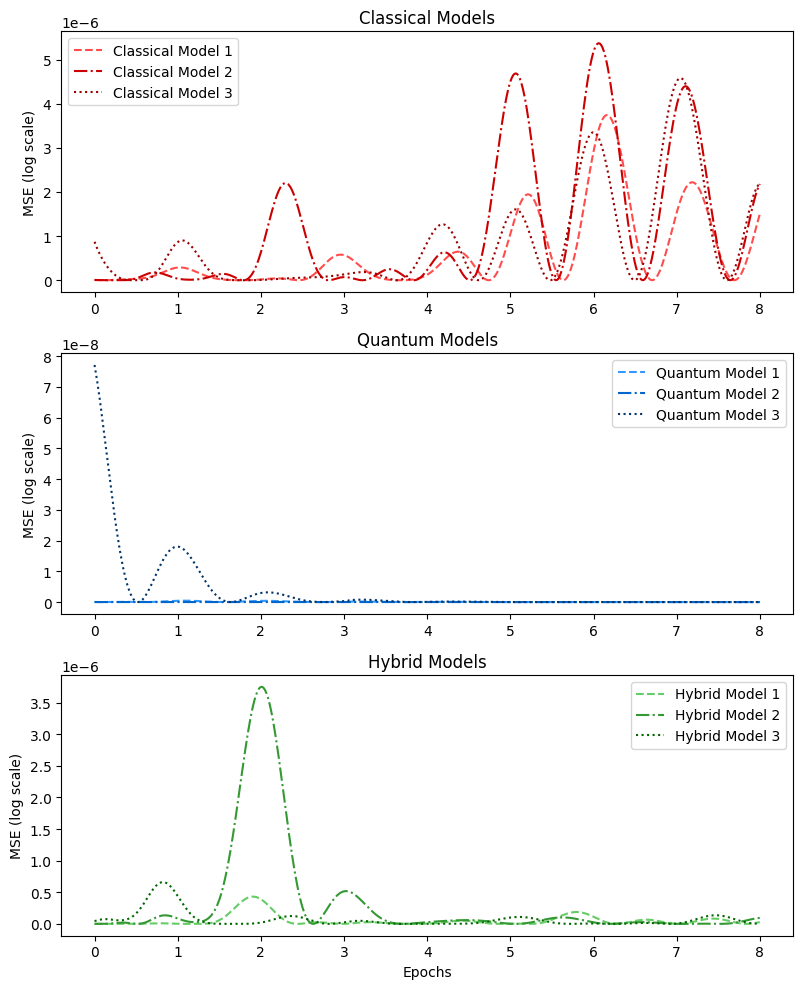

In [27]:
# Example data: replace with your actual MSE lists
# Each group has 3 lines
mse_classical = [np.random.rand(100) * 1e-2 for _ in range(3)]
mse_quantum = [np.random.rand(100) * 1e-3 for _ in range(3)]
mse_hybrid = [np.random.rand(100) * 1e-4 for _ in range(3)]

# Line styles and colors
classical_styles = ['--', '-.', ':']
quantum_styles = ['--', '-.', ':']
hybrid_styles = ['--', '-.', ':']

red_shades = ['#ff4d4d', '#cc0000', '#990000']     # Classical
blue_shades = ['#3399ff', '#0066cc', '#003366']    # Quantum
green_shades = ['#66cc66', '#339933', '#006600']   # Hybrid

fig, axs = plt.subplots(3, 1, figsize=(8, 10))



# --- Classical
for i in range(3):
    axs[0].plot(t.cpu(), cl2_error_list[i].detach().numpy(), linestyle=classical_styles[i], color=red_shades[i], label=f'Classical Model {i+1}')
axs[0].set_ylabel('MSE (log scale)')
axs[0].set_title('Classical Models')
axs[0].legend()

# --- Quantum
for i in range(3):
    axs[1].plot(t.cpu(), ql2_error_list[i].detach().numpy(), linestyle=quantum_styles[i], color=blue_shades[i], label=f'Quantum Model {i+1}')
axs[1].set_ylabel('MSE (log scale)')
axs[1].set_title('Quantum Models')
axs[1].legend()

# --- Hybrid
for i in range(3):
    axs[2].plot(t.cpu(), hl2_error_list[i].detach().numpy(), linestyle=hybrid_styles[i], color=green_shades[i], label=f'Hybrid Model {i+1}')
axs[2].set_ylabel('MSE (log scale)')
axs[2].set_xlabel('Epochs')
axs[2].set_title('Hybrid Models')
axs[2].legend()

plt.tight_layout()
plt.show()
